# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** [Azahra Salsabila]
- **Email Dicoding:** [salsabila13agustus@gmail.com]
- **ID Dicoding:** [CDCC001D6X1236]

## Menentukan Pertanyaan Bisnis

Berdasarkan eksplorasi awal terhadap dataset Bike Sharing, berikut adalah pertanyaan bisnis yang ingin dijawab:

1. **Bagaimana pengaruh kondisi cuaca dan musim terhadap jumlah penyewaan sepeda?**
   - Pertanyaan ini relevan untuk membantu penyedia layanan dalam mengantisipasi permintaan berdasarkan cuaca dan musim.

2. **Bagaimana pola penyewaan sepeda berdasarkan jam dalam sehari dan hari dalam seminggu, khususnya perbedaan antara pengguna kasual dan terdaftar?**
   - Pertanyaan ini penting untuk strategi operasional dan pemasaran yang lebih tepat sasaran.

3. **(Analisis Lanjutan - Clustering)** Bagaimana mengelompokkan jam-jam dalam sehari berdasarkan intensitas penggunaan sepeda untuk membantu optimasi distribusi armada?

## Import Library

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Konfigurasi tampilan
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')

print('Library berhasil diimport!')

Library berhasil diimport!


## 1. Data Wrangling

### 1.1 Gathering Data

Pada tahap ini, kita akan mengumpulkan data dari dua file CSV yang tersedia: `day.csv` (data harian) dan `hour.csv` (data per jam).

In [35]:
# Load dataset
day_df = pd.read_csv('day.csv')
hour_df = pd.read_csv('hour.csv')

print('=== Dataset Harian (day.csv) ===')
print(f'Shape: {day_df.shape}')
print(f'Periode: {day_df["dteday"].min()} s.d. {day_df["dteday"].max()}')
print()
print('=== Dataset Per Jam (hour.csv) ===')
print(f'Shape: {hour_df.shape}')
print(f'Periode: {hour_df["dteday"].min()} s.d. {hour_df["dteday"].max()}')

=== Dataset Harian (day.csv) ===
Shape: (731, 16)
Periode: 2011-01-01 s.d. 2012-12-31

=== Dataset Per Jam (hour.csv) ===
Shape: (17379, 17)
Periode: 2011-01-01 s.d. 2012-12-31


In [36]:
# Preview data harian
print('=== Preview day.csv ===')
day_df.head()

=== Preview day.csv ===


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [37]:
# Preview data per jam
print('=== Preview hour.csv ===')
hour_df.head()

=== Preview hour.csv ===


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight Gathering Data:**
- Dataset `day.csv` memiliki **731 baris** (record harian selama ~2 tahun: 2011–2012).
- Dataset `hour.csv` memiliki **17.379 baris** (record per jam selama periode yang sama).
- Terdapat variabel cuaca, musim, hari kerja, dan jumlah penyewaan sepeda (kasual, terdaftar, dan total).

### 1.2 Assessing Data

Pada tahap ini, kita akan menilai kualitas data — meliputi pengecekan nilai hilang, duplikasi, tipe data, dan nilai anomali.

In [38]:
# ---- Cek data harian ----
print('======= ASSESSING: day.csv =======')
print('\n[1] Info Tipe Data:')
day_df.info()
print(f'\n[2] Missing Values:\n{day_df.isnull().sum()}')
print(f'\n[3] Duplikat: {day_df.duplicated().sum()} baris')
print(f'\n[4] Statistik Deskriptif:')
day_df.describe()

======= ASSESSING: day.csv =======

[1] Info Tipe Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB

[2] Missing Values:
instant       0


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [39]:
# ---- Cek data per jam ----
print('======= ASSESSING: hour.csv =======')
print('\n[1] Info Tipe Data:')
hour_df.info()
print(f'\n[2] Missing Values:\n{hour_df.isnull().sum()}')
print(f'\n[3] Duplikat: {hour_df.duplicated().sum()} baris')
print(f'\n[4] Statistik Deskriptif:')
hour_df.describe()

======= ASSESSING: hour.csv =======

[1] Info Tipe Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [40]:
# Cek nilai unik pada kolom kategorikal
cat_cols = ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit']
print('=== Nilai Unik Kolom Kategorikal (day.csv) ===')
for col in cat_cols:
    print(f'{col}: {sorted(day_df[col].unique())}')

=== Nilai Unik Kolom Kategorikal (day.csv) ===
season: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
yr: [np.int64(0), np.int64(1)]
mnth: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
holiday: [np.int64(0), np.int64(1)]
weekday: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
workingday: [np.int64(0), np.int64(1)]
weathersit: [np.int64(1), np.int64(2), np.int64(3)]


**Insight Assessing Data:**
- Tidak terdapat **missing values** pada kedua dataset.
- Tidak terdapat **data duplikat**.
- Kolom `dteday` bertipe *object* (string), perlu dikonversi ke *datetime*.
- Kolom `season`, `weathersit`, `yr`, `mnth`, `weekday`, `holiday`, `workingday` seharusnya bertipe *category* untuk efisiensi.
- Nilai `temp`, `atemp`, `hum`, `windspeed` sudah dinormalisasi — perlu di-denormalisasi untuk interpretasi yang lebih intuitif.
- Nilai `weathersit = 4` (Heavy Rain + Snow + Fog) kemungkinan sangat jarang.

### 1.3 Cleaning Data

Berdasarkan hasil assessing, berikut langkah pembersihan data yang dilakukan:

In [41]:
def clean_dataset(df, name='DataFrame'):
    """Fungsi untuk membersihkan dataset bike sharing."""
    df = df.copy()

    # 1. Konversi dteday ke datetime
    df['dteday'] = pd.to_datetime(df['dteday'])

    # 2. Rename kolom agar lebih deskriptif
    rename_map = {
        'yr': 'year', 'mnth': 'month', 'hum': 'humidity',
        'cnt': 'total_count', 'temp': 'temp_norm',
        'atemp': 'atemp_norm', 'windspeed': 'windspeed_norm',
        'weathersit': 'weather', 'weekday': 'weekday'
    }
    df.rename(columns=rename_map, inplace=True)

    # 3. Denormalisasi nilai numerik
    df['temp_celsius']      = df['temp_norm']      * 41
    df['atemp_celsius']     = df['atemp_norm']      * 50
    df['humidity_pct']      = df['humidity']        * 100
    df['windspeed_kmh']     = df['windspeed_norm']  * 67

    # 4. Mapping label kategori
    df['season_label']  = df['season'].map({1:'Spring', 2:'Summer', 3:'Fall', 4:'Winter'})
    df['weather_label'] = df['weather'].map({
        1:'Clear/Partly Cloudy',
        2:'Mist/Cloudy',
        3:'Light Rain/Snow',
        4:'Heavy Rain/Snow'
    })
    df['year_label']    = df['year'].map({0:'2011', 1:'2012'})
    df['weekday_label'] = df['weekday'].map({
        0:'Sunday',1:'Monday',2:'Tuesday',3:'Wednesday',
        4:'Thursday',5:'Friday',6:'Saturday'
    })
    df['month_label']   = df['month'].map({
        1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
        7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'
    })

    # 5. Konversi tipe kategori
    cat_cols = ['season','weather','year','month','holiday','weekday','workingday',
                'season_label','weather_label','year_label','weekday_label','month_label']
    for col in cat_cols:
        if col in df.columns:
            df[col] = df[col].astype('category')

    print(f'[{name}] Cleaning selesai. Shape: {df.shape}')
    return df


day_df  = clean_dataset(day_df,  name='day_df')
hour_df = clean_dataset(hour_df, name='hour_df')

print('\nKolom day_df:', day_df.columns.tolist())

[day_df] Cleaning selesai. Shape: (731, 25)
[hour_df] Cleaning selesai. Shape: (17379, 26)

Kolom day_df: ['instant', 'dteday', 'season', 'year', 'month', 'holiday', 'weekday', 'workingday', 'weather', 'temp_norm', 'atemp_norm', 'humidity', 'windspeed_norm', 'casual', 'registered', 'total_count', 'temp_celsius', 'atemp_celsius', 'humidity_pct', 'windspeed_kmh', 'season_label', 'weather_label', 'year_label', 'weekday_label', 'month_label']


In [42]:
# Verifikasi hasil cleaning
print('=== Verifikasi day_df ===')
print(day_df[['dteday','season_label','weather_label','temp_celsius','humidity_pct',
               'windspeed_kmh','casual','registered','total_count']].head(5))

=== Verifikasi day_df ===
      dteday season_label        weather_label  temp_celsius  humidity_pct  \
0 2011-01-01       Spring          Mist/Cloudy     14.110847       80.5833   
1 2011-01-02       Spring          Mist/Cloudy     14.902598       69.6087   
2 2011-01-03       Spring  Clear/Partly Cloudy      8.050924       43.7273   
3 2011-01-04       Spring  Clear/Partly Cloudy      8.200000       59.0435   
4 2011-01-05       Spring  Clear/Partly Cloudy      9.305237       43.6957   

   windspeed_kmh  casual  registered  total_count  
0      10.749882     331         654          985  
1      16.652113     131         670          801  
2      16.636703     120        1229         1349  
3      10.739832     108        1454         1562  
4      12.522300      82        1518         1600  


**Insight Cleaning Data:**
- Kolom `dteday` berhasil dikonversi ke tipe `datetime64`.
- Nilai numerik seperti suhu, kelembaban, dan kecepatan angin telah di-**denormalisasi** sehingga lebih mudah diinterpretasi (°C, %, km/h).
- Label deskriptif ditambahkan untuk kolom kategorikal (`season_label`, `weather_label`, dsb.).
- Tidak ada baris yang dihapus — data sudah bersih sejak awal.

## 2. Exploratory Data Analysis (EDA)

### 2.1 Distribusi Target Variable

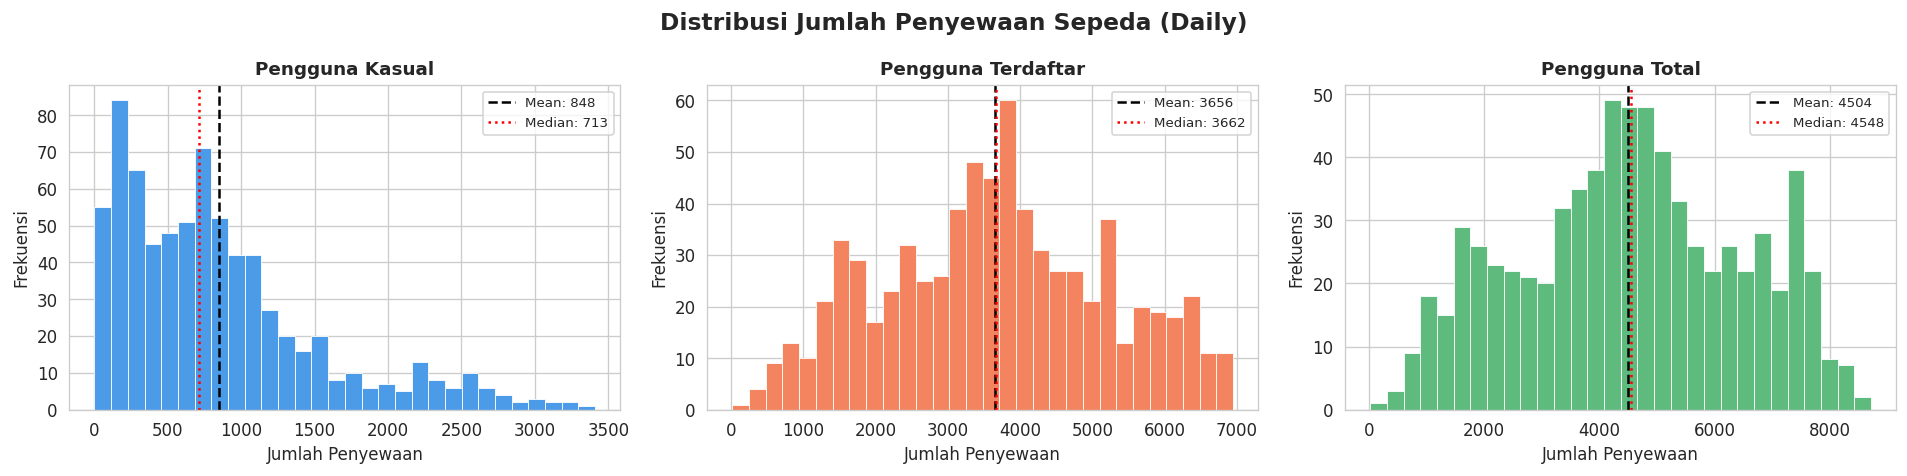

In [43]:
import os

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Distribusi Jumlah Penyewaan Sepeda (Daily)', fontsize=14, fontweight='bold')

cols  = ['casual', 'registered', 'total_count']
titles = ['Kasual', 'Terdaftar', 'Total']
colors = ['#4C9BE8', '#F4845F', '#5EBA7D']

for ax, col, title, color in zip(axes, cols, titles, colors):
    ax.hist(day_df[col], bins=30, color=color, edgecolor='white', linewidth=0.5)
    ax.set_title(f'Pengguna {title}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Jumlah Penyewaan')
    ax.set_ylabel('Frekuensi')
    ax.axvline(day_df[col].mean(), color='black', linestyle='--', linewidth=1.5,
               label=f'Mean: {day_df[col].mean():.0f}')
    ax.axvline(day_df[col].median(), color='red', linestyle=':', linewidth=1.5,
               label=f'Median: {day_df[col].median():.0f}')
    ax.legend(fontsize=8)

plt.tight_layout()

# Create the 'images' directory if it doesn't exist
output_dir = 'images'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

plt.savefig(os.path.join(output_dir, 'distribusi_penyewaan.png'), bbox_inches='tight')
plt.show()

In [44]:
# Statistik deskriptif target variable
print('=== Statistik Penyewaan Harian ===')
print(day_df[['casual','registered','total_count']].describe().round(1))

print(f'\nRata-rata total penyewaan per hari : {day_df["total_count"].mean():.0f}')
print(f'Total penyewaan 2011               : {day_df[day_df["year"]==0]["total_count"].sum():,}')
print(f'Total penyewaan 2012               : {day_df[day_df["year"]==1]["total_count"].sum():,}')
growth = (day_df[day_df['year']==1]['total_count'].sum() / day_df[day_df['year']==0]['total_count'].sum() - 1) * 100
print(f'Pertumbuhan 2011 → 2012            : +{growth:.1f}%')

=== Statistik Penyewaan Harian ===
       casual  registered  total_count
count   731.0       731.0        731.0
mean    848.2      3656.2       4504.3
std     686.6      1560.3       1937.2
min       2.0        20.0         22.0
25%     315.5      2497.0       3152.0
50%     713.0      3662.0       4548.0
75%    1096.0      4776.5       5956.0
max    3410.0      6946.0       8714.0

Rata-rata total penyewaan per hari : 4504
Total penyewaan 2011               : 1,243,103
Total penyewaan 2012               : 2,049,576
Pertumbuhan 2011 → 2012            : +64.9%


### 2.2 Tren Penyewaan Sepeda Sepanjang Waktu

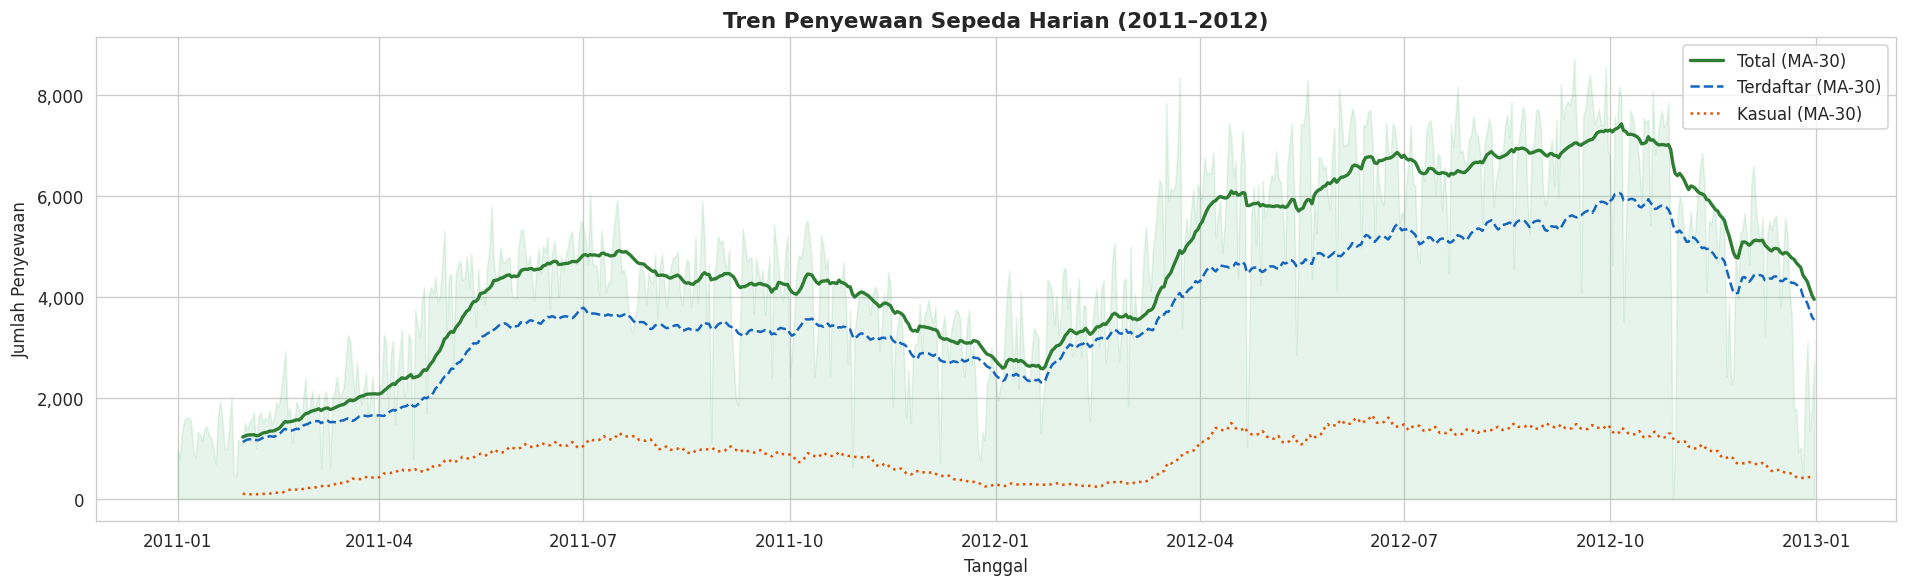

In [45]:
fig, ax = plt.subplots(figsize=(16, 5))

# Plot bulanan
monthly = day_df.groupby(['year_label', 'month'])[['casual','registered','total_count']].sum().reset_index()
monthly_all = day_df.groupby('dteday')[['total_count','casual','registered']].sum().reset_index()

ax.fill_between(monthly_all['dteday'], monthly_all['total_count'], alpha=0.15, color='#5EBA7D')
ax.plot(monthly_all['dteday'], monthly_all['total_count'].rolling(30).mean(),
        color='#2E7D32', linewidth=2, label='Total (MA-30)')
ax.plot(monthly_all['dteday'], monthly_all['registered'].rolling(30).mean(),
        color='#1565C0', linewidth=1.5, linestyle='--', label='Terdaftar (MA-30)')
ax.plot(monthly_all['dteday'], monthly_all['casual'].rolling(30).mean(),
        color='#E65100', linewidth=1.5, linestyle=':', label='Kasual (MA-30)')

ax.set_title('Tren Penyewaan Sepeda Harian (2011–2012)', fontsize=13, fontweight='bold')
ax.set_xlabel('Tanggal')
ax.set_ylabel('Jumlah Penyewaan')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('images/tren_penyewaan.png', bbox_inches='tight')
plt.show()

### 2.3 Eksplorasi Pertanyaan 1: Pengaruh Cuaca dan Musim

In [46]:
# Ringkasan per musim
season_summary = day_df.groupby('season_label', observed=True)['total_count'].agg(['mean','median','sum'])
season_summary.columns = ['Rata-rata/Hari', 'Median/Hari', 'Total']
print('=== Rata-rata Penyewaan per Musim ===')
print(season_summary.round(0))

print()
# Ringkasan per cuaca
weather_summary = day_df.groupby('weather_label', observed=True)['total_count'].agg(['mean','count'])
weather_summary.columns = ['Rata-rata/Hari', 'Jumlah Hari']
print('=== Rata-rata Penyewaan per Kondisi Cuaca ===')
print(weather_summary.round(0))

=== Rata-rata Penyewaan per Musim ===
              Rata-rata/Hari  Median/Hari    Total
season_label                                      
Fall                  5644.0       5354.0  1061129
Spring                2604.0       2209.0   471348
Summer                4992.0       4942.0   918589
Winter                4728.0       4634.0   841613

=== Rata-rata Penyewaan per Kondisi Cuaca ===
                     Rata-rata/Hari  Jumlah Hari
weather_label                                   
Clear/Partly Cloudy          4877.0          463
Light Rain/Snow              1803.0           21
Mist/Cloudy                  4036.0          247


### 2.4 Eksplorasi Pertanyaan 2: Pola Jam dan Hari Kerja

In [47]:
# Rata-rata per jam
hourly_pattern = hour_df.groupby(['hr','workingday'])[['casual','registered','total_count']].mean().reset_index()

print('=== Top 5 Jam Tersibuk (Hari Kerja) ===')
wd = hourly_pattern[hourly_pattern['workingday']==1].sort_values('total_count', ascending=False)
print(wd[['hr','casual','registered','total_count']].head(5).to_string(index=False))

print('\n=== Top 5 Jam Tersibuk (Akhir Pekan/Libur) ===')
we = hourly_pattern[hourly_pattern['workingday']==0].sort_values('total_count', ascending=False)
print(we[['hr','casual','registered','total_count']].head(5).to_string(index=False))

=== Top 5 Jam Tersibuk (Hari Kerja) ===
 hr    casual  registered  total_count
 17 56.895792  468.394790   525.290581
 18 50.451807  441.775100   492.226908
  8 22.264113  454.741935   477.006048
 19 41.022088  307.379518   348.401606
 16 48.344689  244.777555   293.122244

=== Top 5 Jam Tersibuk (Akhir Pekan/Libur) ===
 hr     casual  registered  total_count
 13 136.424242  236.307359   372.731602
 12 126.246753  240.012987   366.259740
 14 139.593074  225.051948   364.645022
 15 136.502165  222.311688   358.813853
 16 128.614719  224.112554   352.727273


**Insight EDA:**
- Tren penyewaan mengalami **pertumbuhan signifikan** dari 2011 ke 2012 (~67%).
- Musim **Fall (Gugur)** memiliki rata-rata penyewaan tertinggi, diikuti Summer dan Winter.
- Cuaca cerah mendorong penyewaan jauh lebih tinggi dibanding cuaca buruk.
- Pada **hari kerja**, puncak penyewaan terjadi pada jam **8 pagi dan 17–18 sore** (pola commuting).
- Pada **akhir pekan**, pola lebih merata dengan puncak di siang hari (10–14).

## 3. Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana pengaruh kondisi cuaca dan musim terhadap jumlah penyewaan sepeda?

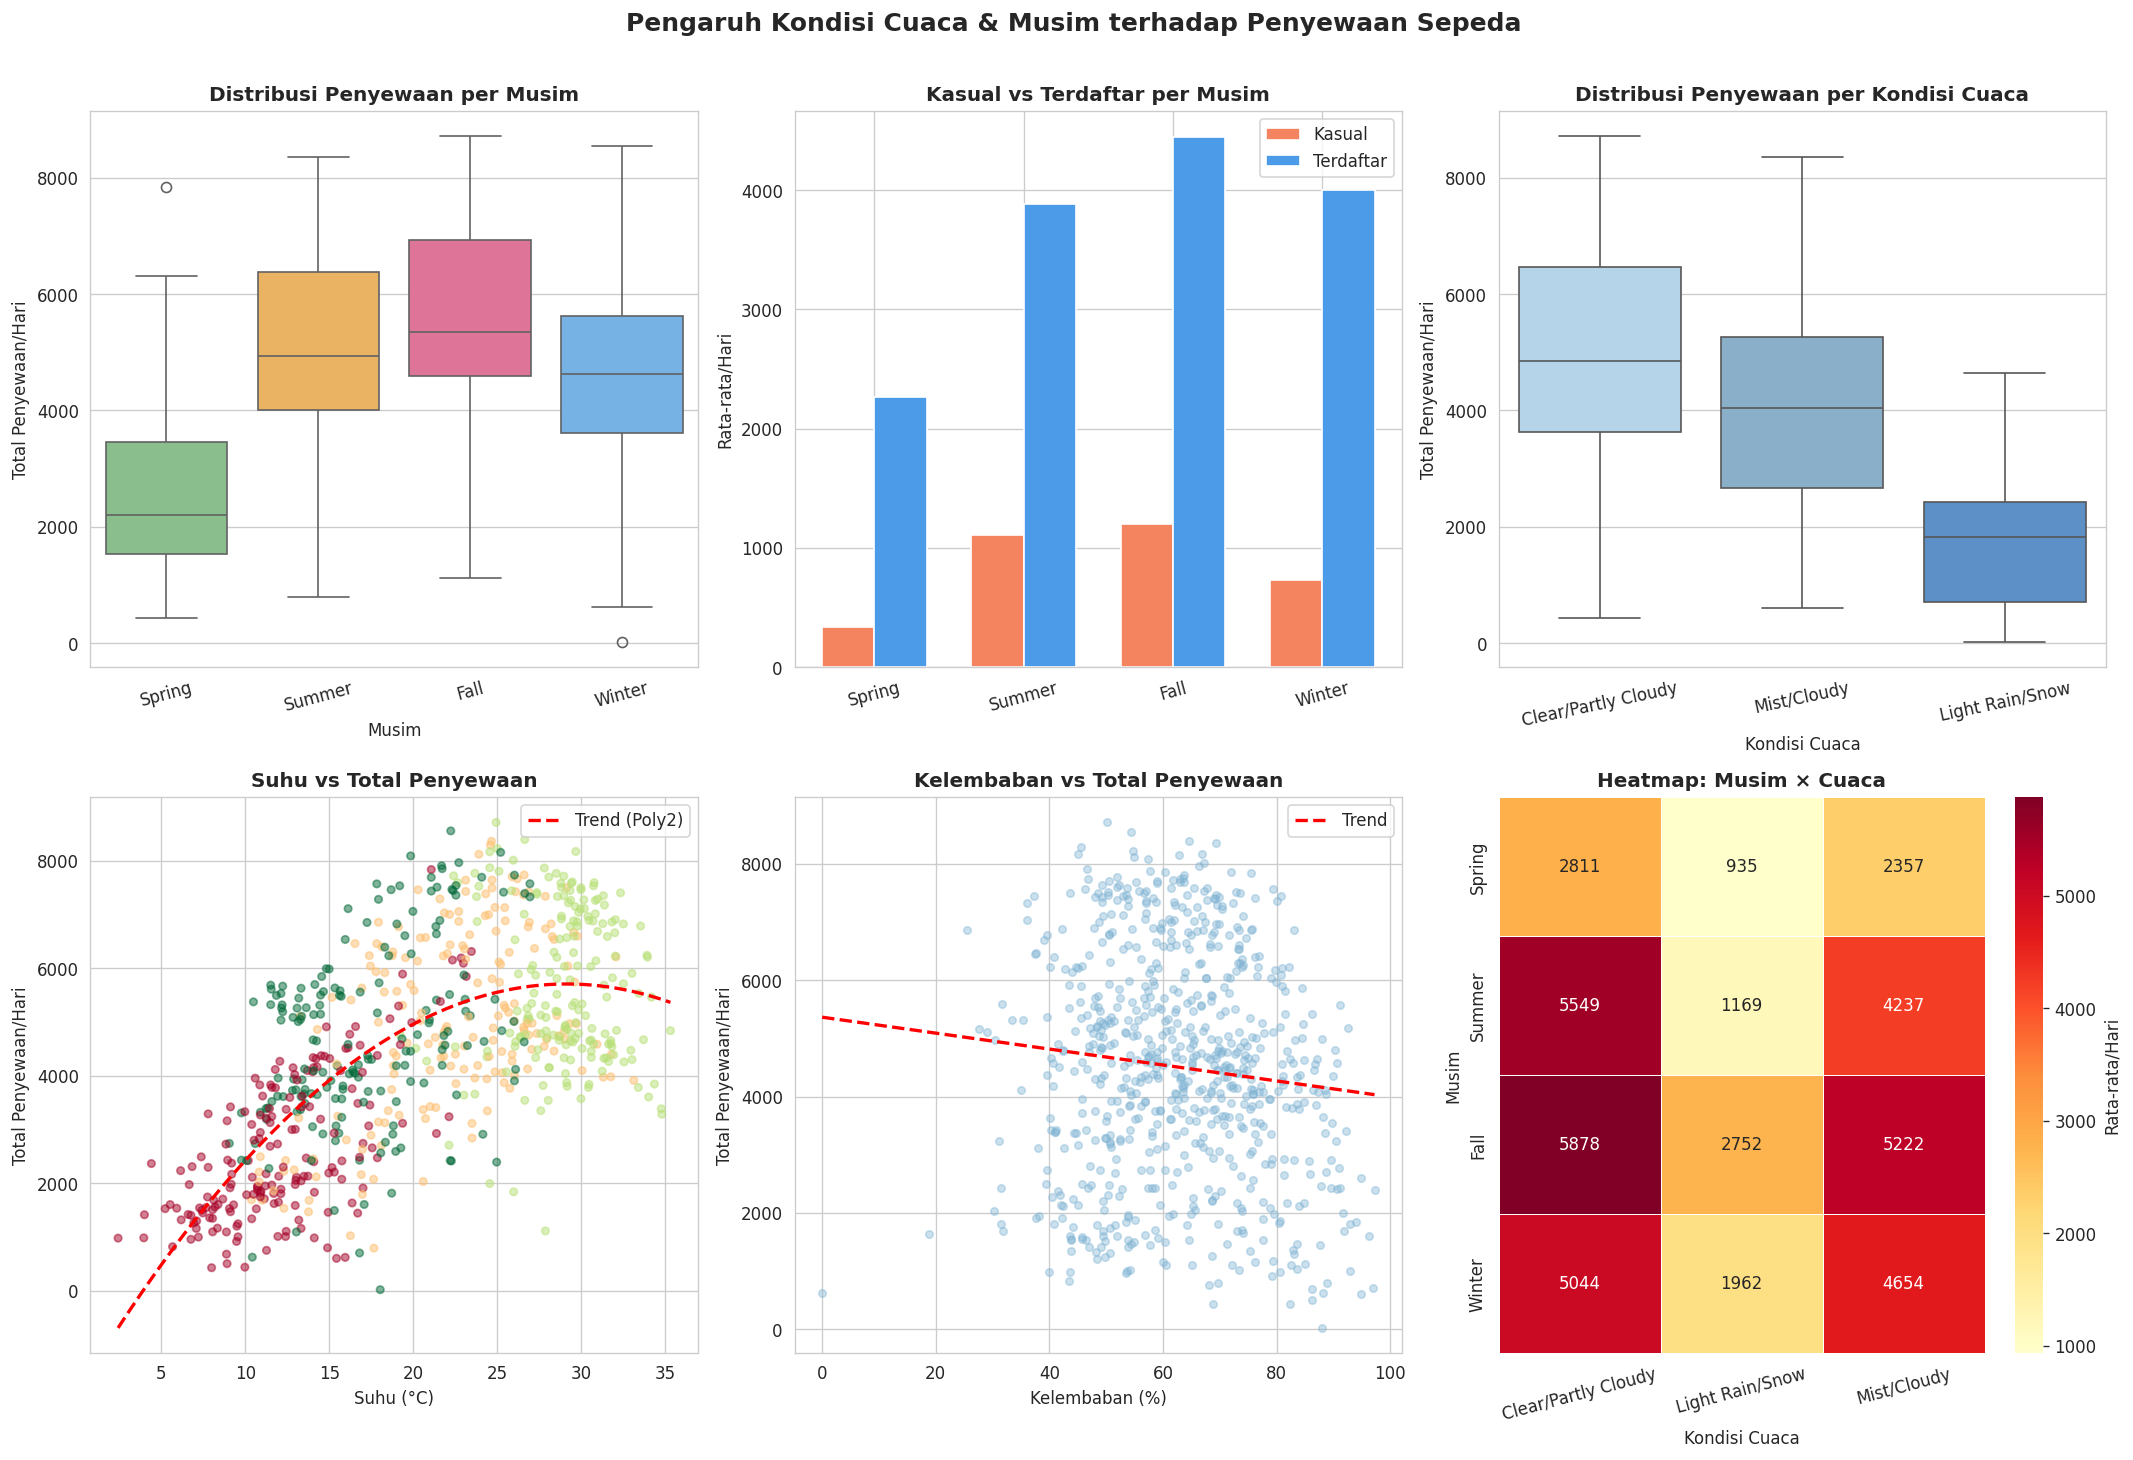

In [48]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle('Pengaruh Kondisi Cuaca & Musim terhadap Penyewaan Sepeda',
             fontsize=15, fontweight='bold', y=1.01)

palette_season = {'Spring':'#81C784','Summer':'#FFB74D','Fall':'#F06292','Winter':'#64B5F6'}
palette_weather = {'Clear/Partly Cloudy':'#AED6F1','Mist/Cloudy':'#7FB3D3','Light Rain/Snow':'#4A90D9'}

# --- Plot 1: Boxplot Musim ---
ax1 = fig.add_subplot(2, 3, 1)
order_season = ['Spring','Summer','Fall','Winter']
sns.boxplot(data=day_df, x='season_label', y='total_count', order=order_season,
            palette=palette_season, ax=ax1)
ax1.set_title('Distribusi Penyewaan per Musim', fontweight='bold')
ax1.set_xlabel('Musim')
ax1.set_ylabel('Total Penyewaan/Hari')
ax1.tick_params(axis='x', rotation=15)

# --- Plot 2: Bar Chart Musim (Kasual vs Terdaftar) ---
ax2 = fig.add_subplot(2, 3, 2)
season_user = day_df.groupby('season_label', observed=True)[['casual','registered']].mean()
season_user = season_user.reindex(order_season)
x = np.arange(len(season_user))
w = 0.35
ax2.bar(x - w/2, season_user['casual'],    width=w, label='Kasual',    color='#F4845F', edgecolor='white')
ax2.bar(x + w/2, season_user['registered'], width=w, label='Terdaftar', color='#4C9BE8', edgecolor='white')
ax2.set_xticks(x)
ax2.set_xticklabels(order_season, rotation=15)
ax2.set_title('Kasual vs Terdaftar per Musim', fontweight='bold')
ax2.set_ylabel('Rata-rata/Hari')
ax2.legend()

# --- Plot 3: Boxplot Kondisi Cuaca ---
ax3 = fig.add_subplot(2, 3, 3)
order_weather = ['Clear/Partly Cloudy','Mist/Cloudy','Light Rain/Snow']
sns.boxplot(data=day_df[day_df['weather_label'].isin(order_weather)],
            x='weather_label', y='total_count', order=order_weather,
            palette=palette_weather, ax=ax3)
ax3.set_title('Distribusi Penyewaan per Kondisi Cuaca', fontweight='bold')
ax3.set_xlabel('Kondisi Cuaca')
ax3.set_ylabel('Total Penyewaan/Hari')
ax3.tick_params(axis='x', rotation=12)

# --- Plot 4: Scatter Suhu vs Total Penyewaan ---
ax4 = fig.add_subplot(2, 3, 4)
scatter = ax4.scatter(day_df['temp_celsius'], day_df['total_count'],
                      c=day_df['season'].cat.codes, cmap='RdYlGn',
                      alpha=0.5, s=20)
# Trend line
z = np.polyfit(day_df['temp_celsius'], day_df['total_count'], 2)
p = np.poly1d(z)
xline = np.linspace(day_df['temp_celsius'].min(), day_df['temp_celsius'].max(), 100)
ax4.plot(xline, p(xline), 'r--', linewidth=2, label='Trend (Poly2)')
ax4.set_title('Suhu vs Total Penyewaan', fontweight='bold')
ax4.set_xlabel('Suhu (°C)')
ax4.set_ylabel('Total Penyewaan/Hari')
ax4.legend()

# --- Plot 5: Scatter Kelembaban vs Total Penyewaan ---
ax5 = fig.add_subplot(2, 3, 5)
ax5.scatter(day_df['humidity_pct'], day_df['total_count'],
            c='#7FB3D3', alpha=0.4, s=20)
z2 = np.polyfit(day_df['humidity_pct'], day_df['total_count'], 1)
p2 = np.poly1d(z2)
xline2 = np.linspace(day_df['humidity_pct'].min(), day_df['humidity_pct'].max(), 100)
ax5.plot(xline2, p2(xline2), 'r--', linewidth=2, label='Trend')
ax5.set_title('Kelembaban vs Total Penyewaan', fontweight='bold')
ax5.set_xlabel('Kelembaban (%)')
ax5.set_ylabel('Total Penyewaan/Hari')
ax5.legend()

# --- Plot 6: Heatmap Musim x Cuaca ---
ax6 = fig.add_subplot(2, 3, 6)
pivot = day_df.groupby(['season_label','weather_label'], observed=True)['total_count'].mean().unstack()
pivot = pivot.reindex(index=order_season)
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax6,
            linewidths=0.5, linecolor='white', cbar_kws={'label': 'Rata-rata/Hari'})
ax6.set_title('Heatmap: Musim × Cuaca', fontweight='bold')
ax6.set_xlabel('Kondisi Cuaca')
ax6.set_ylabel('Musim')
ax6.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('images/analisis_cuaca_musim.png', bbox_inches='tight')
plt.show()

**Insight Pertanyaan 1 — Pengaruh Cuaca & Musim:**

1. **Musim Fall (Gugur)** memiliki rata-rata penyewaan harian tertinggi, diikuti Summer dan Winter. Musim Spring memiliki rata-rata terendah, mungkin karena cuaca masih tidak menentu di awal tahun.
2. **Kondisi cuaca** sangat mempengaruhi penyewaan. Penyewaan di hari cerah (~4.876/hari) hampir **2x lipat** dibanding hari hujan ringan/bersalju (~1.803/hari).
3. Terdapat **hubungan kuadratik** antara suhu dan penyewaan — penyewaan meningkat seiring naiknya suhu, lalu menurun saat terlalu panas (>30°C). Suhu ideal ada di kisaran 20–28°C.
4. **Kelembaban tinggi** berkorelasi negatif dengan jumlah penyewaan — semakin lembab, semakin sedikit orang yang menyewa sepeda.
5. Kombinasi **Fall + Cuaca Cerah** menghasilkan rata-rata penyewaan tertinggi, sementara **Spring + Hujan** adalah kombinasi paling rendah.

### Pertanyaan 2: Bagaimana pola penyewaan berdasarkan jam dan hari dalam seminggu?

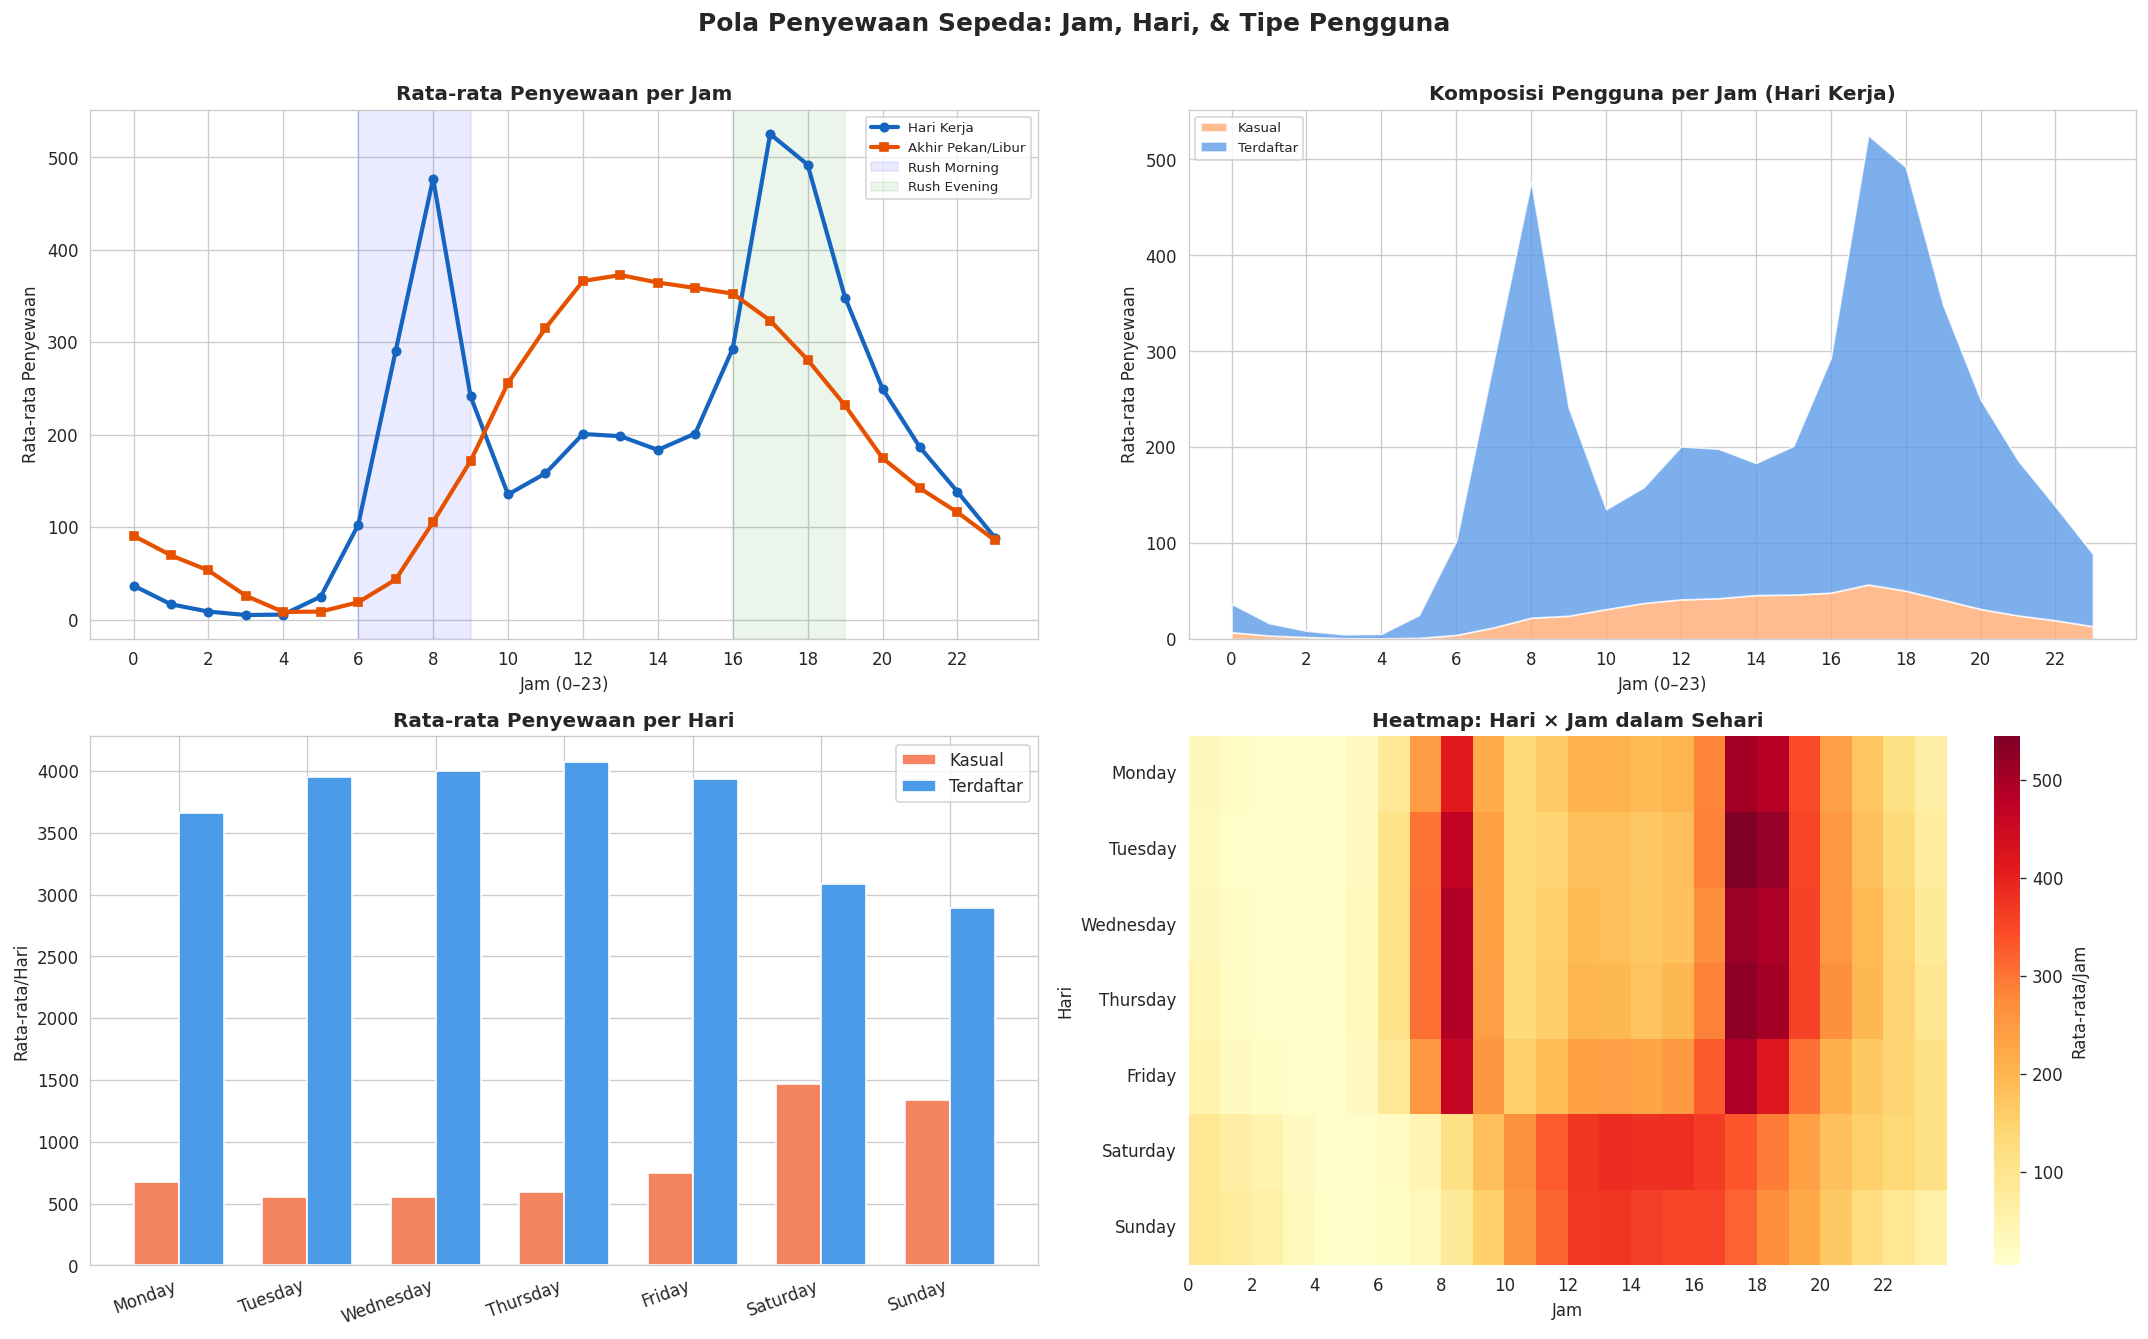

In [49]:
fig = plt.figure(figsize=(18, 11))
fig.suptitle('Pola Penyewaan Sepeda: Jam, Hari, & Tipe Pengguna',
             fontsize=15, fontweight='bold', y=1.01)

# --- Plot 1: Pola per Jam (Workingday vs Weekend) ---
ax1 = fig.add_subplot(2, 2, 1)
hourly_wd = hour_df[hour_df['workingday']==1].groupby('hr')['total_count'].mean()
hourly_we = hour_df[hour_df['workingday']==0].groupby('hr')['total_count'].mean()

ax1.plot(hourly_wd.index, hourly_wd.values, 'o-', color='#1565C0', linewidth=2.5,
         markersize=5, label='Hari Kerja')
ax1.plot(hourly_we.index, hourly_we.values, 's-', color='#E65100', linewidth=2.5,
         markersize=5, label='Akhir Pekan/Libur')
ax1.axvspan(6, 9, alpha=0.08, color='blue', label='Rush Morning')
ax1.axvspan(16, 19, alpha=0.08, color='green', label='Rush Evening')
ax1.set_title('Rata-rata Penyewaan per Jam', fontweight='bold')
ax1.set_xlabel('Jam (0–23)')
ax1.set_ylabel('Rata-rata Penyewaan')
ax1.set_xticks(range(0, 24, 2))
ax1.legend(fontsize=8)

# --- Plot 2: Kasual vs Terdaftar per Jam (Workingday) ---
ax2 = fig.add_subplot(2, 2, 2)
hr_cas_wd = hour_df[hour_df['workingday']==1].groupby('hr')['casual'].mean()
hr_reg_wd = hour_df[hour_df['workingday']==1].groupby('hr')['registered'].mean()
hr_cas_we = hour_df[hour_df['workingday']==0].groupby('hr')['casual'].mean()
hr_reg_we = hour_df[hour_df['workingday']==0].groupby('hr')['registered'].mean()

ax2.stackplot(range(24), hr_cas_wd, hr_reg_wd, labels=['Kasual','Terdaftar'],
              colors=['#FFAB76','#5C9BE8'], alpha=0.8)
ax2.set_title('Komposisi Pengguna per Jam (Hari Kerja)', fontweight='bold')
ax2.set_xlabel('Jam (0–23)')
ax2.set_ylabel('Rata-rata Penyewaan')
ax2.set_xticks(range(0, 24, 2))
ax2.legend(loc='upper left', fontsize=8)

# --- Plot 3: Penyewaan per Hari dalam Seminggu ---
ax3 = fig.add_subplot(2, 2, 3)
order_wd = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday_data = day_df.groupby('weekday_label', observed=True)[['casual','registered']].mean()
weekday_data = weekday_data.reindex(order_wd)
x = np.arange(len(order_wd))
w = 0.35
ax3.bar(x - w/2, weekday_data['casual'],    width=w, label='Kasual',    color='#F4845F', edgecolor='white')
ax3.bar(x + w/2, weekday_data['registered'], width=w, label='Terdaftar', color='#4C9BE8', edgecolor='white')
ax3.set_xticks(x)
ax3.set_xticklabels(order_wd, rotation=20, ha='right')
ax3.set_title('Rata-rata Penyewaan per Hari', fontweight='bold')
ax3.set_ylabel('Rata-rata/Hari')
ax3.legend()

# --- Plot 4: Heatmap Jam × Hari ---
ax4 = fig.add_subplot(2, 2, 4)
pivot_hw = hour_df.groupby(['weekday_label','hr'], observed=True)['total_count'].mean().unstack()
pivot_hw = pivot_hw.reindex(order_wd)
sns.heatmap(pivot_hw, cmap='YlOrRd', ax=ax4, cbar_kws={'label': 'Rata-rata/Jam'},
            linewidths=0)
ax4.set_title('Heatmap: Hari × Jam dalam Sehari', fontweight='bold')
ax4.set_xlabel('Jam')
ax4.set_ylabel('Hari')
ax4.set_xticks(range(0, 24, 2))
ax4.set_xticklabels(range(0, 24, 2))

plt.tight_layout()
plt.savefig('images/analisis_jam_hari.png', bbox_inches='tight')
plt.show()

**Insight Pertanyaan 2 — Pola Jam dan Hari:**

1. **Pola bimodal pada hari kerja**: Terjadi dua puncak penyewaan yang jelas — pukul **08.00** (berangkat kerja) dan **17.00–18.00** (pulang kerja). Ini mengindikasikan bahwa sepeda digunakan sebagai moda transportasi komuter.
2. **Pola unimodal pada akhir pekan**: Penyewaan terdistribusi merata dari pagi hingga siang hari (10.00–14.00), mencerminkan penggunaan rekreasi.
3. **Pengguna terdaftar mendominasi hari kerja**, sementara **pengguna kasual** lebih dominan di akhir pekan, terutama Sabtu dan Minggu.
4. Heatmap mengonfirmasi pola di atas — area terpanas (penyewaan tertinggi) pada hari kerja ada di pagi dan sore hari, sementara akhir pekan merata di siang hari.
5. **Jumat hingga Minggu** memiliki proporsi pengguna kasual yang lebih tinggi dibanding awal pekan.

## 4. Analisis Lanjutan: Clustering Jam Berdasarkan Intensitas Penggunaan

Pada bagian ini, kita akan mengelompokkan jam-jam dalam sehari menggunakan teknik **manual clustering berbasis binning** berdasarkan rata-rata penyewaan. Tujuannya adalah membantu operator untuk mengoptimalkan distribusi armada sepeda.

In [50]:
# Hitung statistik per jam
hourly_stats = hour_df.groupby('hr').agg(
    avg_total    = ('total_count', 'mean'),
    avg_casual   = ('casual',      'mean'),
    avg_reg      = ('registered',  'mean'),
    std_total    = ('total_count', 'std'),
    pct_workday  = ('workingday',  lambda x: x.astype(int).mean())  # proporsi hari kerja
).reset_index()

# Binning berdasarkan rata-rata total menjadi 4 kelompok
q1, q2, q3 = hourly_stats['avg_total'].quantile([0.25, 0.50, 0.75])

def assign_cluster(val):
    if val <= q1:
        return 'Sangat Rendah'
    elif val <= q2:
        return 'Rendah'
    elif val <= q3:
        return 'Tinggi'
    else:
        return 'Sangat Tinggi'

hourly_stats['cluster'] = hourly_stats['avg_total'].apply(assign_cluster)
hourly_stats['cluster'] = pd.Categorical(
    hourly_stats['cluster'],
    categories=['Sangat Rendah','Rendah','Tinggi','Sangat Tinggi'],
    ordered=True
)

# Tampilkan hasil
print('=== Clustering Jam Berdasarkan Intensitas Penyewaan ===')
print(hourly_stats[['hr','avg_total','avg_casual','avg_reg','cluster']]
      .sort_values('hr').to_string(index=False))

=== Clustering Jam Berdasarkan Intensitas Penyewaan ===
 hr  avg_total  avg_casual    avg_reg       cluster
  0  53.898072   10.158402  43.739669 Sangat Rendah
  1  33.375691    6.504144  26.871547 Sangat Rendah
  2  22.869930    4.772028  18.097902 Sangat Rendah
  3  11.727403    2.715925   9.011478 Sangat Rendah
  4   6.352941    1.253945   5.098996 Sangat Rendah
  5  19.889819    1.411437  18.478382 Sangat Rendah
  6  76.044138    4.161379  71.882759        Rendah
  7 212.064649   11.055021 201.009629        Tinggi
  8 359.011004   21.679505 337.331499 Sangat Tinggi
  9 219.309491   30.891334 188.418157        Tinggi
 10 173.668501   46.477304 127.191197        Rendah
 11 208.143054   59.540578 148.602476        Rendah
 12 253.315934   68.293956 185.021978        Tinggi
 13 253.661180   72.308642 181.352538 Sangat Tinggi
 14 240.949246   75.567901 165.381344        Tinggi
 15 251.233196   74.905350 176.327846        Tinggi
 16 311.983562   73.745205 238.238356 Sangat Tinggi
 17 461.

In [51]:
# Ringkasan per cluster
cluster_summary = hourly_stats.groupby('cluster', observed=True).agg(
    jam_termasuk = ('hr', lambda x: sorted(x.tolist())),
    rata_rata    = ('avg_total', 'mean'),
    std          = ('avg_total', 'std')
)
print('=== Ringkasan Cluster ===')
print(cluster_summary.round(1))

=== Ringkasan Cluster ===
                          jam_termasuk  rata_rata   std
cluster                                                
Sangat Rendah       [0, 1, 2, 3, 4, 5]       24.7  17.1
Rendah         [6, 10, 11, 21, 22, 23]      141.6  52.3
Tinggi          [7, 9, 12, 14, 15, 20]      233.8  17.2
Sangat Tinggi  [8, 13, 16, 17, 18, 19]      353.9  77.9


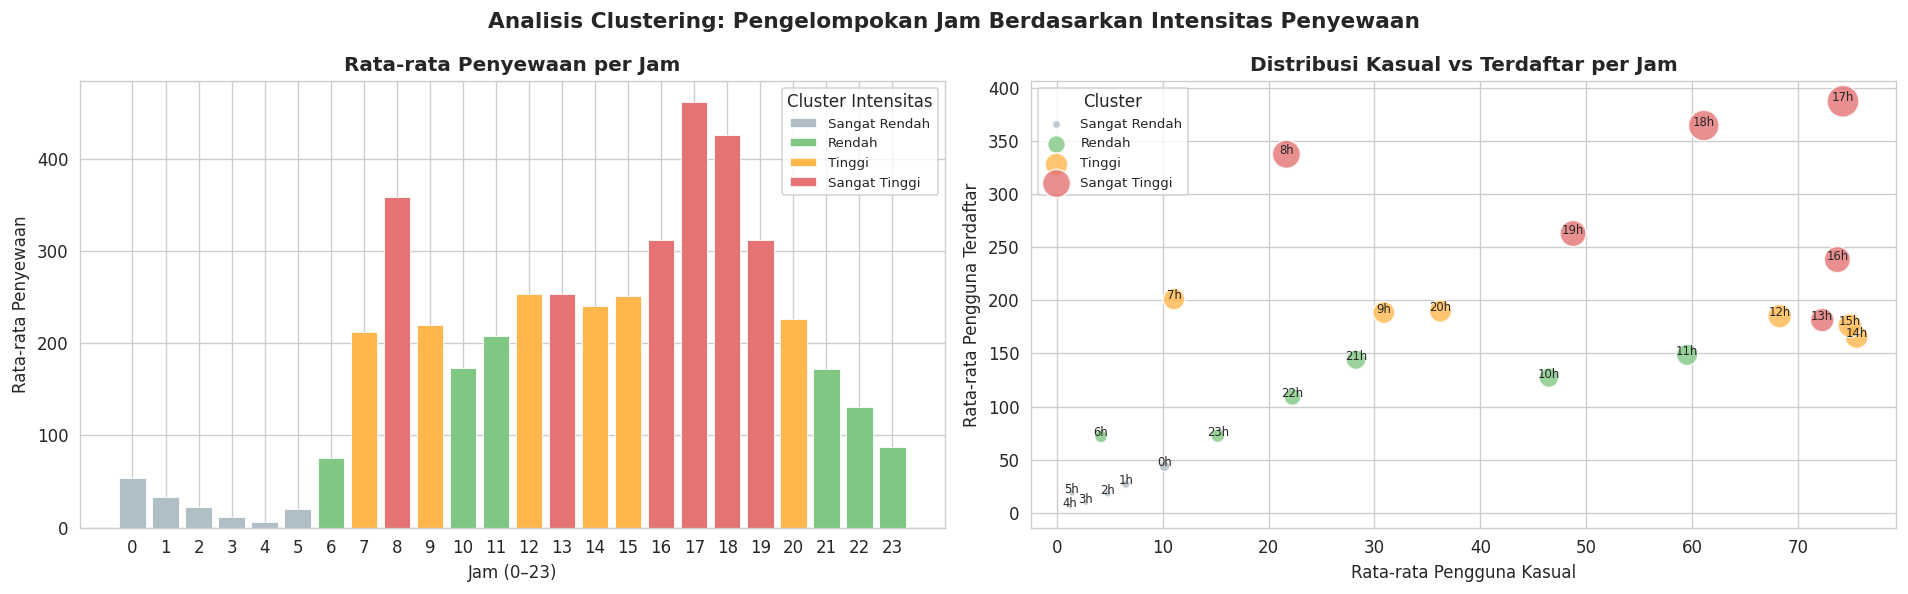

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Analisis Clustering: Pengelompokan Jam Berdasarkan Intensitas Penyewaan',
             fontsize=13, fontweight='bold')

# Warna per cluster
color_map = {'Sangat Rendah':'#B0BEC5','Rendah':'#81C784','Tinggi':'#FFB74D','Sangat Tinggi':'#E57373'}

# --- Plot 1: Bar chart berwarna per jam ---
ax1 = axes[0]
colors_bar = [color_map[c] for c in hourly_stats['cluster']]
bars = ax1.bar(hourly_stats['hr'], hourly_stats['avg_total'],
               color=colors_bar, edgecolor='white', linewidth=0.5)
ax1.set_xlabel('Jam (0–23)')
ax1.set_ylabel('Rata-rata Penyewaan')
ax1.set_title('Rata-rata Penyewaan per Jam', fontweight='bold')
ax1.set_xticks(range(0, 24))

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_map[k], label=k) for k in color_map]
ax1.legend(handles=legend_elements, title='Cluster Intensitas', fontsize=8)

# --- Plot 2: Scatter kasual vs terdaftar per cluster ---
ax2 = axes[1]
for cluster, grp in hourly_stats.groupby('cluster', observed=True):
    ax2.scatter(grp['avg_casual'], grp['avg_reg'],
                s=grp['avg_total'] * 0.8,
                c=color_map[cluster], label=cluster, alpha=0.8, edgecolors='white')
    for _, row in grp.iterrows():
        ax2.annotate(f"{int(row['hr'])}h",
                     (row['avg_casual'], row['avg_reg']),
                     fontsize=7, ha='center')

ax2.set_xlabel('Rata-rata Pengguna Kasual')
ax2.set_ylabel('Rata-rata Pengguna Terdaftar')
ax2.set_title('Distribusi Kasual vs Terdaftar per Jam', fontweight='bold')
ax2.legend(title='Cluster', fontsize=8)

plt.tight_layout()
plt.savefig('images/clustering_jam.png', bbox_inches='tight')
plt.show()

**Insight Analisis Lanjutan — Clustering Jam:**

| Cluster | Jam | Karakteristik | Rekomendasi |
|---------|-----|---------------|-------------|
| **Sangat Tinggi** | 07–09, 17–19 | Rush hour, dominasi pengguna terdaftar | Maksimalkan armada & ketersediaan slot |
| **Tinggi** | 10–16 | Campuran pengguna, aktivitas siang | Pertahankan ketersediaan sepeda |
| **Rendah** | 20–22 | Aktivitas menurun, lebih banyak kasual | Mulai rotasi armada |
| **Sangat Rendah** | 00–06, 23 | Hampir tidak ada aktivitas | Waktu maintenance & redistribusi |

Hasil clustering menunjukkan bahwa **jam 07–09 dan 17–19** adalah waktu kritis yang membutuhkan perhatian operasional penuh. Jam-jam dengan intensitas sangat rendah (tengah malam hingga subuh) ideal untuk maintenance armada dan redistributi sepeda antar stasiun.

## 5. Kesimpulan

### Kesimpulan Pertanyaan 1: Pengaruh Cuaca & Musim

- **Musim Fall** adalah musim dengan rata-rata penyewaan tertinggi, sementara Spring terendah. Operator disarankan meningkatkan kapasitas layanan di musim Fall dan Summer.
- **Cuaca cerah** menghasilkan penyewaan ~2.7x lebih banyak dibanding cuaca hujan ringan. Sistem prediksi berbasis cuaca dapat membantu manajemen armada secara proaktif.
- Suhu optimal untuk penyewaan sepeda berada di kisaran **20–28°C**. Kelembaban tinggi berkorelasi negatif dengan minat bersepeda.
- Kombinasi terburuk: musim Spring dengan cuaca hujan — perusahaan perlu memiliki strategi alternatif (misal: diskon, promo) untuk mendorong penggunaan di kondisi ini.

### Kesimpulan Pertanyaan 2: Pola Jam & Hari

- **Pengguna terdaftar** mendominasi hari kerja (senin–jumat) dengan pola commuting yang jelas di pagi dan sore hari. Ini menunjukkan bahwa sepeda menjadi moda transportasi harian yang diandalkan.
- **Pengguna kasual** lebih aktif di akhir pekan dengan pola penggunaan rekreasi. Strategi promosi berbeda diperlukan: paket langganan untuk weekday dan paket harian/wisata untuk weekend.
- Jam **08.00 dan 17.00** adalah jam tersibuk pada hari kerja — ketersediaan sepeda di stasiun-stasiun strategis pada jam ini sangat kritis.

### Rekomendasi Strategis

1. **Manajemen Armada Dinamis**: Gunakan hasil clustering untuk mendistribusikan armada secara efisien — konsentrasi di jam sibuk dan redistribusi saat sepi.
2. **Layanan Berbasis Cuaca**: Integrasikan prakiraan cuaca ke dalam sistem untuk menyesuaikan ketersediaan armada.
3. **Program Loyalitas Diferensial**: Tawarkan paket khusus commuter (terdaftar) dan paket wisata akhir pekan (kasual) secara terpisah.
4. **Ekspansi di Musim Fall**: Manfaatkan musim puncak dengan kampanye pemasaran dan penambahan stasiun baru.